# Train Model Workflow

This notebook mirrors `train_model.py`, organized into logical steps.

## 1. Imports

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib

## 2. Load And Prepare Dataset

In [61]:
# Load dataset
df = pd.read_csv('dataset.csv')
df = df.sort_values(by='game_date')  # Sort by date

In [62]:
df.drop(columns=['fast_break_pct_avg_diff','fast_break_pct_rolling_5_diff','points_off_turnover_pct_avg_diff','points_off_turnover_pct_rolling_5_diff'], inplace=True)

In [63]:
print("Number of nulls per column in df (ordered by highest nulls first):")
null_counts = df.isnull().sum().sort_values(ascending=False)
for col, count in null_counts.items():
    print(f"{col}: {count}")

Number of nulls per column in df (ordered by highest nulls first):
game_id: 0
season: 0
season_type: 0
game_date: 0
team_home_away: 0
team_winner: 0
is_early_season: 0
sos: 0
sos_opp: 0
off_vs_def: 0
def_vs_off: 0
tov_vs_stl: 0
stl_vs_tov: 0
orb_vs_drb: 0
drb_vs_orb: 0
pace_diff: 0
exp_poss: 0
efg_vs_efg_allowed: 0
efg_allowed_vs_efg: 0
margin_estimate: 0
home_off_away_def: 0
home_def_away_off: 0
away_off_home_def: 0
away_def_home_off: 0
last_10_efficiency_diff: 0
team_score_avg_diff: 0
team_score_rolling_5_diff: 0
opponent_team_score_avg_diff: 0
opponent_team_score_rolling_5_diff: 0
poss_avg_diff: 0
poss_rolling_5_diff: 0
poss_opponent_avg_diff: 0
poss_opponent_rolling_5_diff: 0
off_eff_avg_diff: 0
off_eff_rolling_5_diff: 0
def_eff_avg_diff: 0
def_eff_rolling_5_diff: 0
net_eff_avg_diff: 0
net_eff_rolling_5_diff: 0
efg_avg_diff: 0
efg_rolling_5_diff: 0
efg_allowed_avg_diff: 0
efg_allowed_rolling_5_diff: 0
tov_avg_diff: 0
tov_rolling_5_diff: 0
stl_rate_avg_diff: 0
stl_rate_rolling_5_dif

## 3. Train/Test Split And Shared Config

In [64]:
# Split train/test based on date
split_date = '2023-11-01'
df['target'] = df['team_winner']
df.drop(columns=['team_winner'], inplace=True)
train_df = df[df['game_date'] <= split_date].copy()
test_df = df[df['game_date'] > split_date].copy()
train_df.drop(columns=['game_date','game_id'], inplace=True)
test_df.drop(columns=['game_date','game_id'], inplace=True)

In [65]:
train_df.tail(10)

,season,season_type,team_home_away,is_early_season,sos,sos_opp,off_vs_def,def_vs_off,tov_vs_stl,stl_vs_tov,...,block_rate_avg_diff,block_rate_rolling_5_diff,lead_vs_outcome_avg_diff,lead_vs_outcome_rolling_5_diff,conference_strength_diff,win_loss_pct_diff,non_conf_win_loss_pct_diff,conference_nonconf_win_pct_diff,luck_diff,target
191638,2023,3,2,1,9.476278,1.439704,-0.334835,10.500770,-0.125517,-0.085796,...,-0.031340,-0.020942,1.470588,-2.2,2.890065,-0.205882,0.036717,0.068637,0.072988,0
191639,2023,3,2,1,1.701027,-2.636402,20.101591,10.317292,-0.092844,-0.126646,...,-0.036748,-0.035229,-0.698701,0.2,17.528233,-0.007576,0.211867,0.280770,-0.079498,1
191641,2023,3,2,1,2.107963,1.265485,17.246850,11.007917,-0.130778,-0.108425,...,0.011701,-0.003403,0.769841,1.6,0.008866,-0.043243,0.000000,0.000101,-0.029819,0
191640,2023,3,2,1,1.265485,2.107963,11.007917,17.246850,-0.108425,-0.130778,...,-0.011701,0.003403,-0.769841,-1.6,-0.008866,0.043243,0.000000,-0.000101,0.029819,1
191642,2023,3,2,1,11.357094,3.667586,11.528638,19.728778,-0.094249,-0.119192,...,0.027452,0.038285,1.638889,-1.8,-3.393634,-0.083333,-0.014652,0.002116,-0.004276,1
191643,2023,3,2,1,3.667586,11.357094,19.728778,11.528638,-0.119192,-0.094249,...,-0.027452,-0.038285,-1.638889,1.8,3.393634,0.083333,0.014652,-0.002116,0.004276,0
191644,2023,3,2,1,6.594749,6.807285,14.003904,21.798421,-0.115468,-0.105361,...,0.032257,0.031994,-0.245560,1.8,4.263794,-0.016216,0.128914,0.072571,-0.168592,1
191645,2023,3,2,1,6.807285,6.594749,21.798421,14.003904,-0.105361,-0.115468,...,-0.032257,-0.031994,0.245560,-1.8,-4.263794,0.016216,-0.128914,-0.072571,0.168592,0
191646,2023,3,2,1,6.701223,11.615015,24.336859,11.424509,-0.112110,-0.098194,...,0.014292,-0.012462,-0.738265,0.4,3.429942,-0.048364,0.014154,-0.002030,-0.164257,1
191647,2023,3,2,1,11.615015,6.701223,11.424509,24.336859,-0.098194,-0.112110,...,-0.014292,0.012462,0.738265,-0.4,-3.429942,0.048364,-0.014154,0.002030,0.164257,0


## 4. Train Winner Prediction Model

In [66]:
# Winner prediction model

# Make sure to drop 'target' column before training
X_train = train_df.drop(columns=['target'])
y_train = train_df['target'].astype(int)

X_test = test_df.drop(columns=['target'])
y_test = test_df['target'].astype(int)

print(X_train.columns.to_list())

winner_params = dict(
    objective="binary",
    metric="binary_logloss",
    boosting_type="gbdt",
    learning_rate=0.02,
    n_estimators=4000,
    max_depth=6,
    num_leaves=63,
    min_child_samples=60,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    lambda_l1=0.5,
    lambda_l2=5.0,
    min_gain_to_split=0.01,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

model_winner = LGBMClassifier(**winner_params)

print("\nTraining winner prediction model...")
model_winner.fit(X_train, y_train)

['season', 'season_type', 'team_home_away', 'is_early_season', 'sos', 'sos_opp', 'off_vs_def', 'def_vs_off', 'tov_vs_stl', 'stl_vs_tov', 'orb_vs_drb', 'drb_vs_orb', 'pace_diff', 'exp_poss', 'efg_vs_efg_allowed', 'efg_allowed_vs_efg', 'margin_estimate', 'home_off_away_def', 'home_def_away_off', 'away_off_home_def', 'away_def_home_off', 'last_10_efficiency_diff', 'team_score_avg_diff', 'team_score_rolling_5_diff', 'opponent_team_score_avg_diff', 'opponent_team_score_rolling_5_diff', 'poss_avg_diff', 'poss_rolling_5_diff', 'poss_opponent_avg_diff', 'poss_opponent_rolling_5_diff', 'off_eff_avg_diff', 'off_eff_rolling_5_diff', 'def_eff_avg_diff', 'def_eff_rolling_5_diff', 'net_eff_avg_diff', 'net_eff_rolling_5_diff', 'efg_avg_diff', 'efg_rolling_5_diff', 'efg_allowed_avg_diff', 'efg_allowed_rolling_5_diff', 'tov_avg_diff', 'tov_rolling_5_diff', 'stl_rate_avg_diff', 'stl_rate_rolling_5_diff', 'orb_avg_diff', 'orb_rolling_5_diff', 'drb_avg_diff', 'drb_rolling_5_diff', 'ftr_avg_diff', 'ftr_rol

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,6
,learning_rate,0.02
,n_estimators,4000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,60


## 5. Train Upset Prediction Model

In [67]:
# Upset prediction model
tournament_df = train_df[train_df['season_type'] == 3].copy()
upset_games = tournament_df[
    ((tournament_df['net_eff_avg_diff'] >= 10) & (tournament_df['target'] == 0)) |
    ((tournament_df['net_eff_avg_diff'] > -10) & (tournament_df['target'] == 1))
].copy()
upset_df = pd.concat([tournament_df] + [upset_games.copy() for _ in range(4)], ignore_index=True)  # 5x weight

X_train_upset = upset_df.drop(columns=['target'])
y_train_upset = upset_df['target'].astype(int)

upset_params = dict(
    objective="binary",
    metric="aucpr",   # better for rare-event focus
    boosting_type="gbdt",
    learning_rate=0.015,
    n_estimators=5000,
    max_depth=5,
    num_leaves=31,
    min_child_samples=80,
    feature_fraction=0.75,
    bagging_fraction=0.75,
    bagging_freq=1,
    lambda_l1=0.5,
    lambda_l2=8.0,
    min_gain_to_split=0.02,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


model_upset = LGBMClassifier(**upset_params)

print("\nTraining upset prediction model...")
model_upset.fit(X_train_upset, y_train_upset)


Training upset prediction model...


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.015
,n_estimators,5000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,80


In [73]:
test_tournament_df = test_df[test_df['season_type'] == 3].copy()
X_test_upset = test_tournament_df.drop(columns=['target'])
y_test_upset = test_tournament_df['target'].astype(int)

## 6. Save Models

In [68]:
joblib.dump(model_winner, 'models/lgbm_winner_model.joblib')
joblib.dump(model_upset, 'models/lgbm_upset_model.joblib')

['models/lgbm_upset_model.joblib']

## 7. Define Evaluation Helper

In [77]:
def evaluate_thresholds(model, X_test, y_test, model_name):
    from sklearn.metrics import matthews_corrcoef

    thresholds = np.linspace(0.1, 0.8, 10)  # Test thresholds from 0.1 to 0.8
    metrics = []

    # Create mask for actual 0 values (away team wins)
    actual_zero_mask = (y_test == 0)

    for thresh in thresholds:
        # Get predictions based on threshold
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_thresh = (y_pred_proba > thresh).astype(int)

        # Calculate standard metrics
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)
        accuracy = accuracy_score(y_test, y_pred_thresh)
        mcc = matthews_corrcoef(y_test, y_pred_thresh)

        # Calculate accuracy for cases where the actual value is 0
        # This shows how well the model identifies games where away team wins
        if np.sum(actual_zero_mask) > 0:
            actual_zero_accuracy = accuracy_score(
                y_test[actual_zero_mask],
                y_pred_thresh[actual_zero_mask]
            )
        else:
            actual_zero_accuracy = 0

        metrics.append([thresh, precision, recall, f1, accuracy, actual_zero_accuracy, mcc])

    # Convert to DataFrame
    metrics_df = pd.DataFrame(
        metrics,
        columns=[
            "Threshold", "Precision", "Recall", "F1 Score", "Accuracy", "Accuracy_Actual_0", "Matthews_CC"
        ]
    )

    # Plot metrics
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=metrics_df, x="Threshold", y="Precision", label="Precision", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Recall", label="Recall", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="F1 Score", label="F1 Score", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy", label="Accuracy", marker="o")
    sns.lineplot(
        data=metrics_df,
        x="Threshold",
        y="Accuracy_Actual_0",
        label="Accuracy When Away Team Wins",
        marker="o",
        linestyle="--",
        color="purple"
    )
    sns.lineplot(
        data=metrics_df,
        x="Threshold",
        y="Matthews_CC",
        label="Matthews Corr. Coefficient",
        marker="o",
        linestyle="--",
        color="darkgreen"
    )

    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Optimization - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print count of actual away team wins
    print(f"Number of actual away team wins in test set: {np.sum(actual_zero_mask)}")

    # Find and return the best threshold based on Matthews Correlation Coefficient (MCC)
    best_threshold = metrics_df.loc[metrics_df["Matthews_CC"].idxmax(), "Threshold"]
    return best_threshold

## 8. Evaluate Thresholds

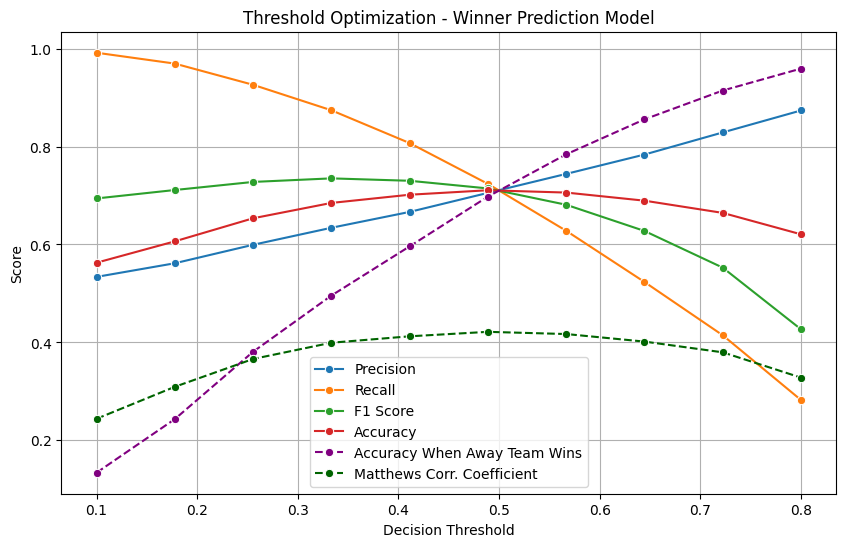

Number of actual away team wins in test set: 16490


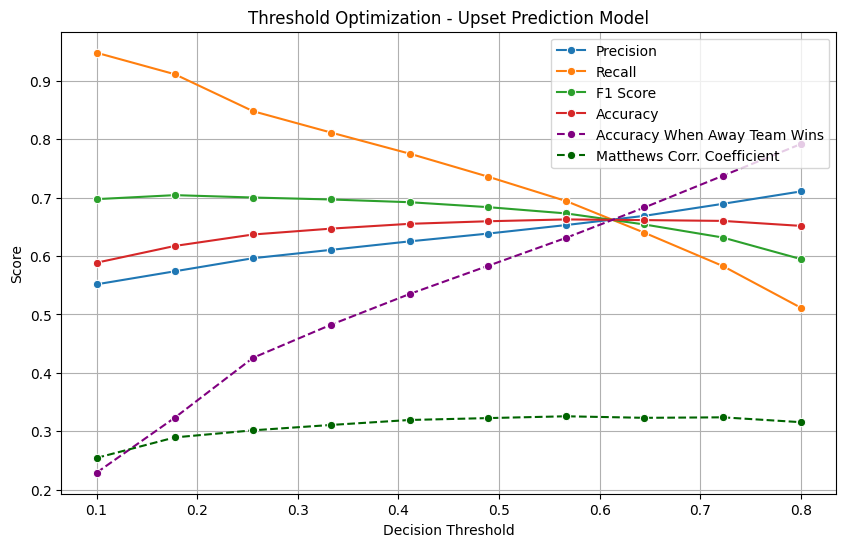

Number of actual away team wins in test set: 16490


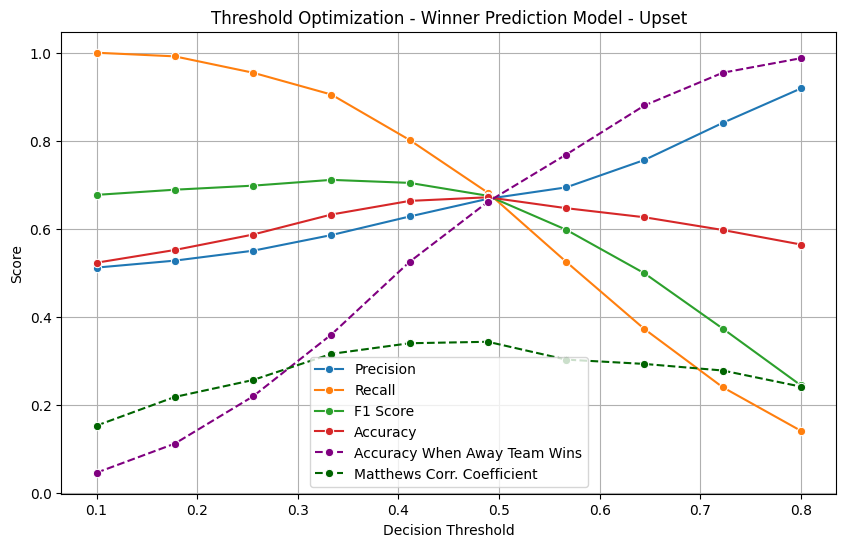

Number of actual away team wins in test set: 242


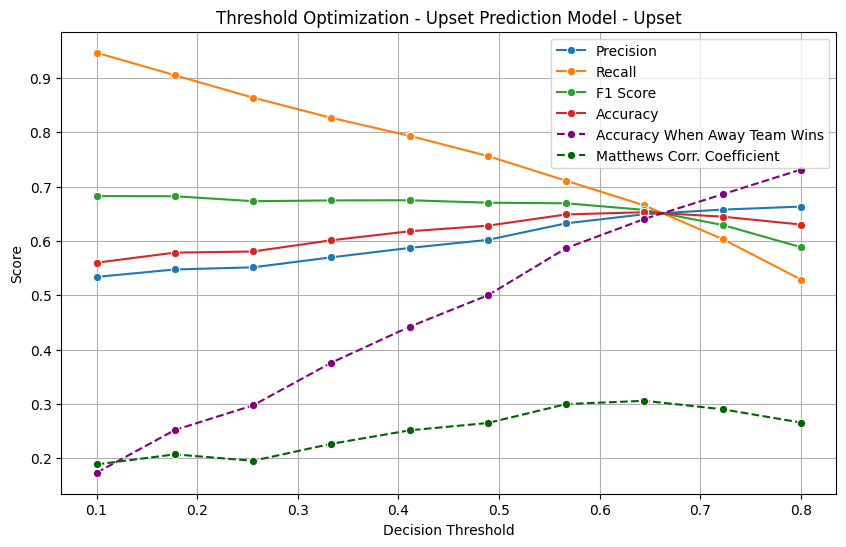

Number of actual away team wins in test set: 242

Optimal Decision Threshold (Winner Model): 0.49
Optimal Decision Threshold (Winner Model - Upset): 0.49


In [79]:
best_thresh_winner = evaluate_thresholds(model_winner, X_test, y_test, "Winner Prediction Model")
best_thresh_upset = evaluate_thresholds(model_upset, X_test, y_test, "Upset Prediction Model")
best_thresh_upset_winner = evaluate_thresholds(model_winner, X_test_upset, y_test_upset, "Winner Prediction Model - Upset")
best_thresh_upset_upset = evaluate_thresholds(model_upset, X_test_upset, y_test_upset, "Upset Prediction Model - Upset")

print(f"\nOptimal Decision Threshold (Winner Model): {best_thresh_winner:.2f}")
print(f"Optimal Decision Threshold (Winner Model - Upset): {best_thresh_upset_winner:.2f}")

## 9. Define Feature Importance Helper

In [71]:
def plot_feature_importance(model, X_train, model_name):
    feature_importances = model.feature_importances_
    feature_names = X_train.columns

    feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    top_20_features = feat_importance_df.sort_values(by="Importance", ascending=False).head(30)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"Top 20 Features - {model_name}")
    plt.show()

## 10. Plot Feature Importances

C:\Users\Alex\AppData\Local\Temp\ipykernel_3480\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


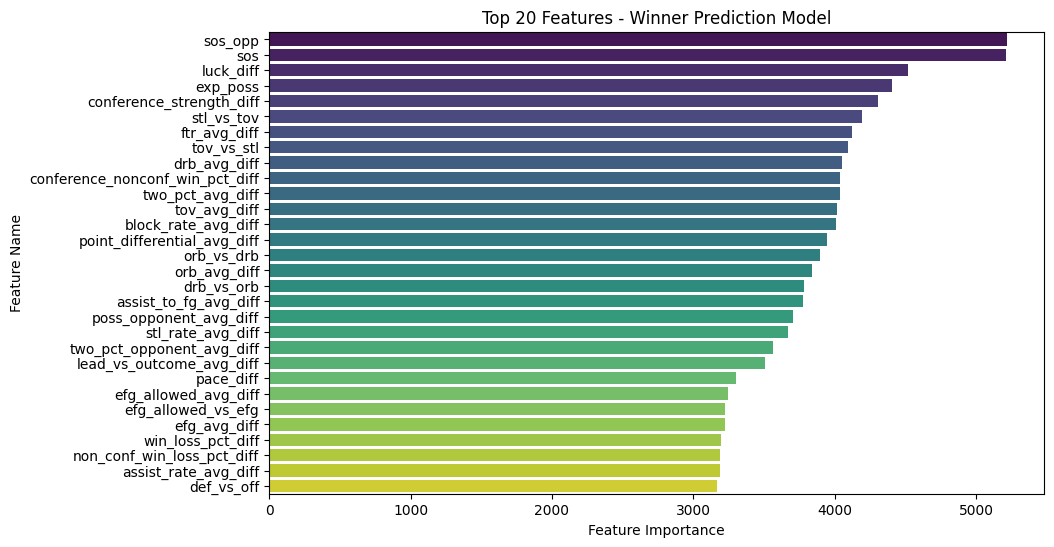

C:\Users\Alex\AppData\Local\Temp\ipykernel_3480\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


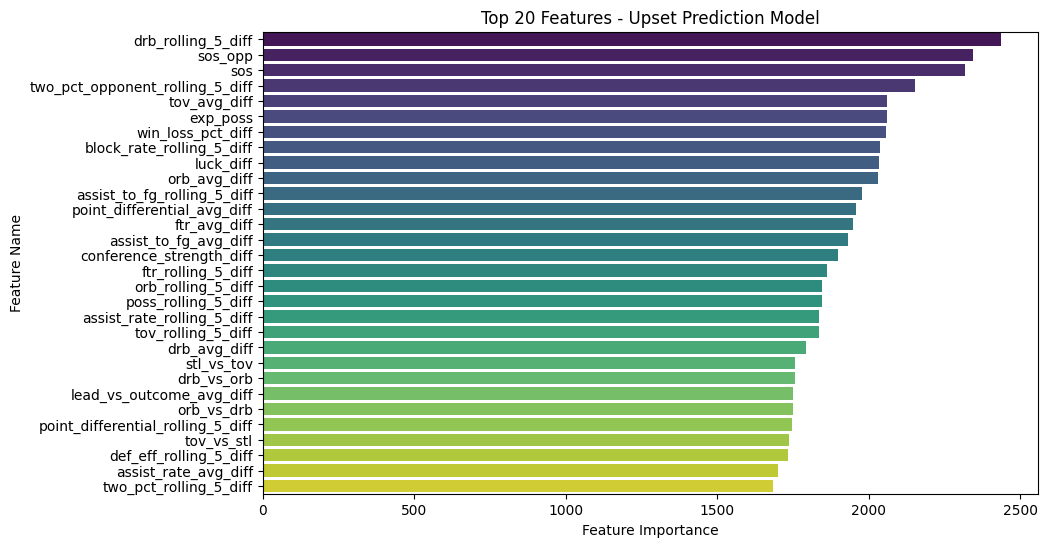

In [72]:
plot_feature_importance(model_winner, X_train, "Winner Prediction Model")
plot_feature_importance(model_upset, X_train_upset, "Upset Prediction Model")